In [ ]:
#importing all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

print("\nDATASET METADATA:")
print(f"Title: {breast_cancer_wisconsin_diagnostic.metadata['name']}")
print(f"Creators: {breast_cancer_wisconsin_diagnostic.metadata['creators']}")
print(f"Donated on: {breast_cancer_wisconsin_diagnostic.metadata['year_of_dataset_creation']}")
print(f"Number of instances: {breast_cancer_wisconsin_diagnostic.metadata['num_instances']}")
print(f"Number of features: {breast_cancer_wisconsin_diagnostic.metadata['num_features']}")
print(f"DOI: {breast_cancer_wisconsin_diagnostic.metadata['dataset_doi']}")

print(breast_cancer_wisconsin_diagnostic.metadata)

# variable information
print(breast_cancer_wisconsin_diagnostic.variables)


DATASET METADATA:
Title: Breast Cancer Wisconsin (Diagnostic)
Creators: ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street']
Donated on: 1993
Number of instances: 569
Number of features: 30
DOI: 10.24432/C5DW2B
{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_

In [ ]:
#checking the structure of X and y
print(f"X type: {type(X)}")
print(f"X shape: {X.shape}")
print(f"\ny type: {type(y)}")
print(f"y shape: {y.shape}")
print(f"\ny columns: {y.columns.tolist()}")
print(f"\nFirst 5 rows of y:")
print(y.head())

X type: <class 'pandas.core.frame.DataFrame'>
X shape: (569, 30)

y type: <class 'pandas.core.frame.DataFrame'>
y shape: (569, 1)

y columns: ['Diagnosis']

First 5 rows of y:
  Diagnosis
0         M
1         M
2         M
3         M
4         M


In [ ]:
#combining into one dataframe
#the target column is named 'diagnosis'
df = X.copy()
df['diagnosis'] = y['Diagnosis']

print(f"Combined dataframe shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nColumn names:")
print(df.columns.tolist())

Combined dataframe shape: (569, 31)

First 5 rows:
   radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3    11.42     20.38       77.58   386.1      0.14250       0.28390   
4    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  concave_points1  symmetry1  fractal_dimension1  ...  texture3  \
0      0.3001          0.14710     0.2419             0.07871  ...     17.33   
1      0.0869          0.07017     0.1812             0.05667  ...     23.41   
2      0.1974          0.12790     0.2069             0.05999  ...     25.53   
3      0.2414          0.10520     0.2597             0.09744  ...     26.50   
4      0.1980          0.10430     0.1809             0.05883  ...     16.67   

   perimeter3   area3  smoothness3  compa

In [ ]:
#checking class distribution
print("CLASS DISTRIBUTION:")
print(df['diagnosis'].value_counts())
benign_count = (df['diagnosis'] == 'B').sum()
malignant_count = (df['diagnosis'] == 'M').sum()
print(f"Benign (B): {benign_count} samples ({benign_count/len(df)*100:.1f}%)")
print(f"Malignant (M): {malignant_count} samples ({malignant_count/len(df)*100:.1f}%)")

CLASS DISTRIBUTION:
diagnosis
B    357
M    212
Name: count, dtype: int64
Benign (B): 357 samples (62.7%)
Malignant (M): 212 samples (37.3%)


In [ ]:
#encoding diagnosis (M=1,B=0)
df['diagnosis_encoded'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [ ]:
#separating features and target
X_features = df.drop(['diagnosis', 'diagnosis_encoded'], axis=1)
y_target = df['diagnosis_encoded']

print(f"Features shape: {X_features.shape}")
print(f"Target shape: {y_target.shape}")

Features shape: (569, 30)
Target shape: (569,)


In [ ]:
#selecting features (Mann-Whitney U Test)

#separating benign and malignant samples
benign = df[df['diagnosis_encoded'] == 0]
malignant = df[df['diagnosis_encoded'] == 1]

results = []
for feature in X_features.columns:
    stat, p_value = mannwhitneyu(benign[feature], malignant[feature], alternative='two-sided')
    results.append({'Feature':feature, 'U-Statistic':stat, 'P-Value':p_value, 'Significant (p<0.05)':p_value < 0.05})

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('P-Value')

print("TOP 10 MOST SIGNIFICANT FEATURES (lowest p-values):")
print(results_df.head(10).to_string(index=False))

top_10_features = results_df.head(10)['Feature'].tolist()
print(f"\nSelected features for modeling: {top_10_features}")

TOP 10 MOST SIGNIFICANT FEATURES (lowest p-values):
        Feature  U-Statistic      P-Value  Significant (p<0.05)
     perimeter3       1858.0 2.583004e-80                  True
        radius3       2237.0 1.135630e-78                  True
          area3       2283.5 1.803309e-78                  True
concave_points3       2520.0 1.863997e-77                  True
concave_points1       2691.5 1.006324e-76                  True
     perimeter1       4019.0 3.553870e-71                  True
          area1       4668.5 1.539780e-68                  True
     concavity1       4705.5 2.164549e-68                  True
        radius1       4729.0 2.692943e-68                  True
          area2       5569.5 5.767823e-65                  True

Selected features for modeling: ['perimeter3', 'radius3', 'area3', 'concave_points3', 'concave_points1', 'perimeter1', 'area1', 'concavity1', 'radius1', 'area2']


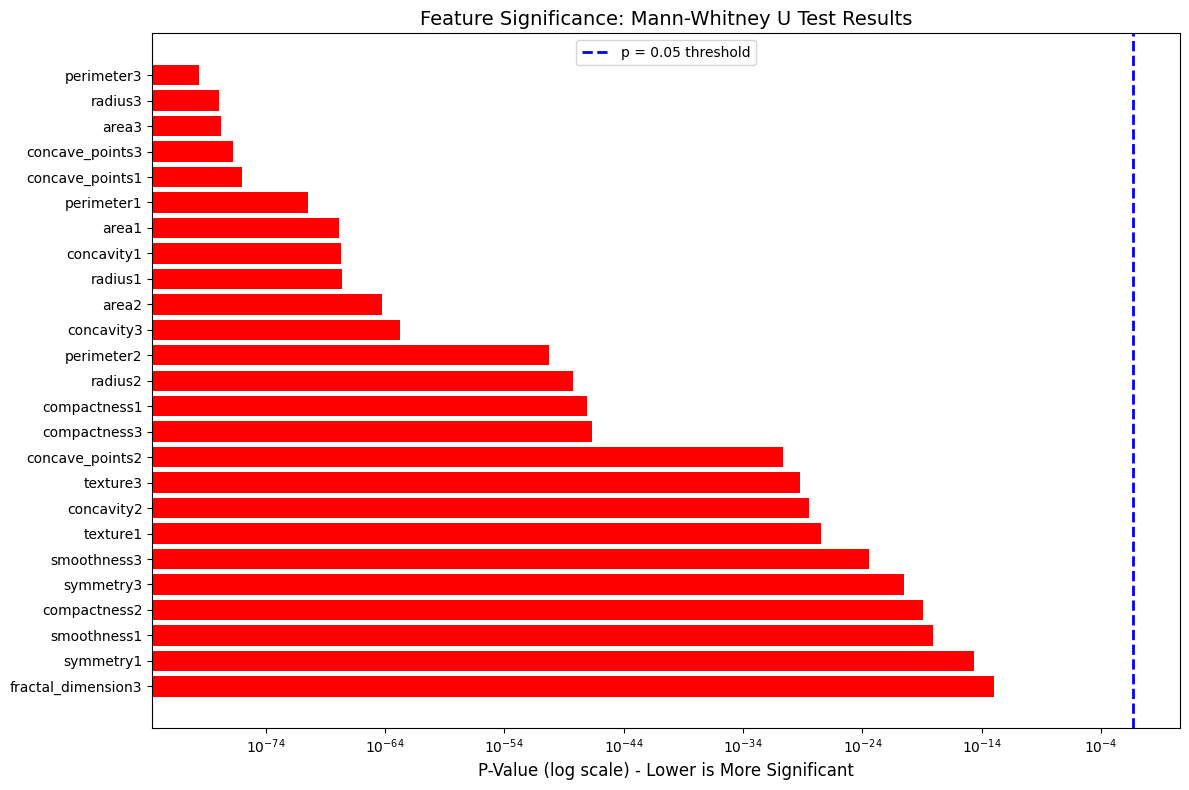

In [ ]:
#visualizing p-values
plt.figure(figsize=(12, 8))
significant = results_df['P-Value'] < 0.05
colors = ['red' if x else 'green' for x in significant]
plt.barh(results_df['Feature'][:25], results_df['P-Value'][:25], color=colors[:25])
plt.axvline(x=0.05, color='blue', linestyle='--', linewidth=2, label='p = 0.05 threshold')
plt.xscale('log')
plt.xlabel('P-Value (log scale) - Lower is More Significant', fontsize=12)
plt.title('Feature Significance: Mann-Whitney U Test Results', fontsize=14)
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

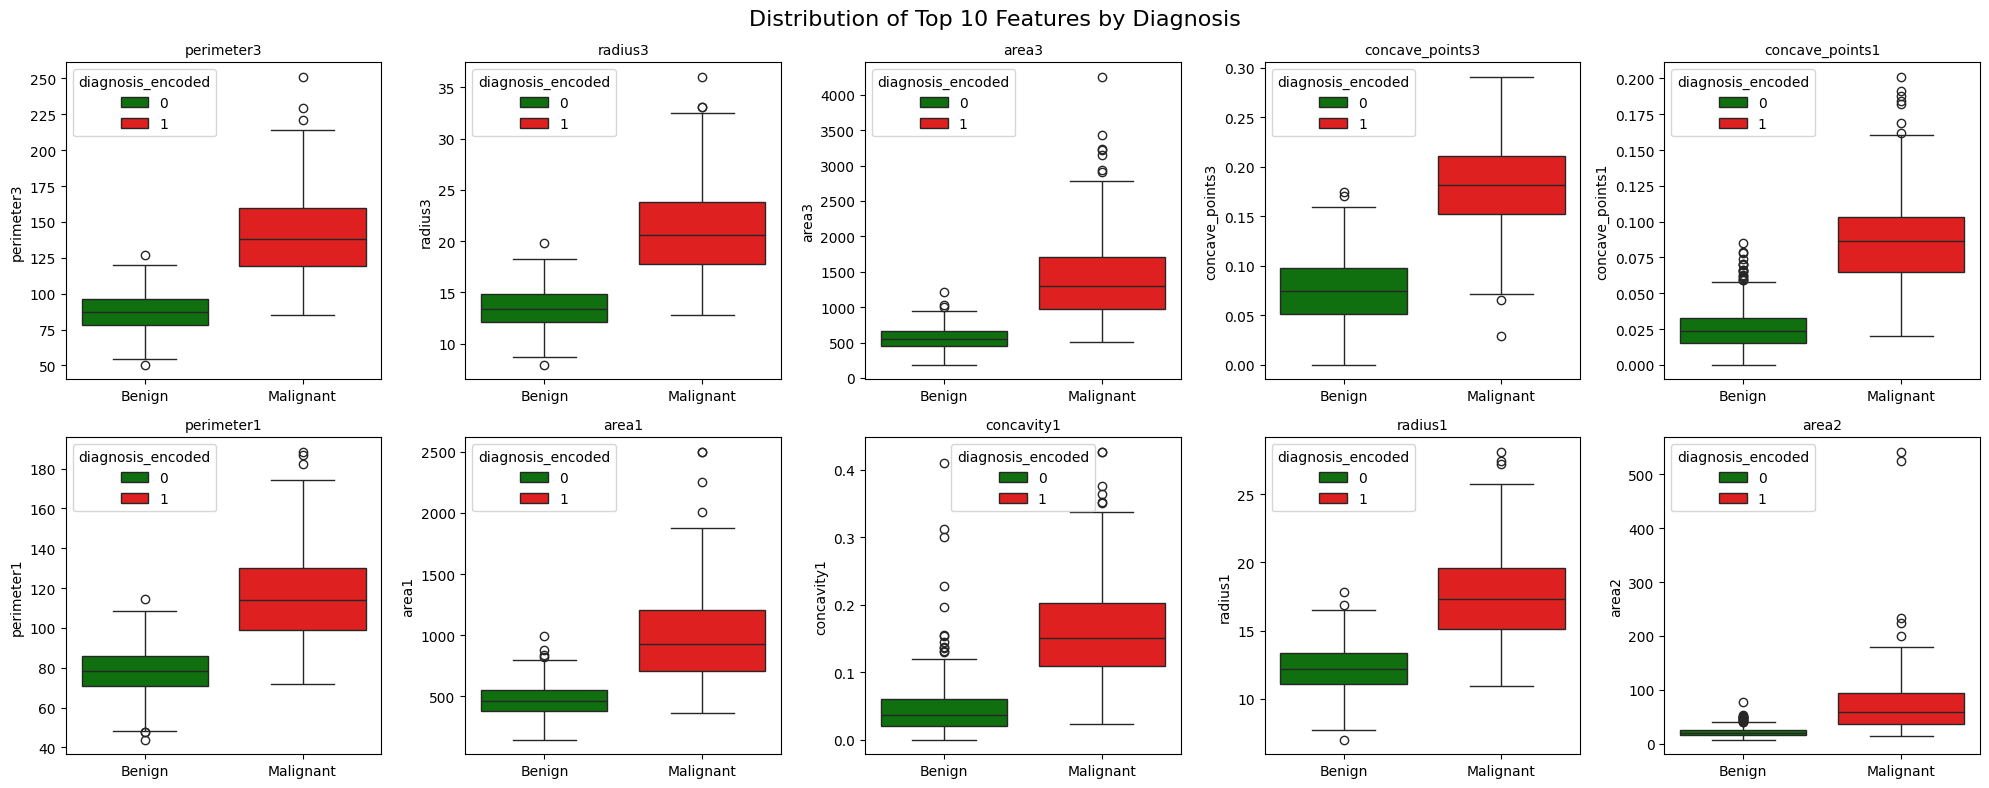

In [ ]:
#boxplots for top features
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(top_10_features[:10]):  # Top 10 features
    sns.boxplot(x='diagnosis_encoded', y=feature, hue='diagnosis_encoded', data=df, ax=axes[i], palette=['green', 'red'])
    axes[i].set_title(f'{feature}', fontsize=10)
    axes[i].set_xticks([0, 1], ['Benign', 'Malignant'])
    axes[i].set_xlabel('')

plt.suptitle('Distribution of Top 10 Features by Diagnosis', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
#preparing data for logistic regression

#we will use only top 10 features
X_selected = X_features[top_10_features]

#splitting data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_target, test_size=0.2, random_state=42, stratify=y_target)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

#standardizing features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set size: 455 samples
Testing set size: 114 samples


In [ ]:
#training logistic regression model

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

#displaying coefficients
print("Model coefficients (log-odds):")
for feature, coef in zip(top_10_features, model.coef_[0]):
    direction = "(INCREASES malignancy risk)" if coef > 0 else "(DECREASES malignancy risk)"
    print(f"  {feature}: {coef:.4f} {direction}")

#Model Interpretations
#calculating Odds Ratios
odds_ratios = np.exp(model.coef_[0])
print("\nODDS RATIOS (Interpretation):")
print("For a one-standard-deviation increase in each feature:")
for feature, odds in zip(top_10_features, odds_ratios):
    if odds > 1:
        print(f"  {feature}: {odds:.4f} -- {((odds-1)*100):.1f}% HIGHER odds of malignancy")
    else:
        print(f"  {feature}: {odds:.4f} -- {((1-odds)*100):.1f}% LOWER odds of malignancy")

Model coefficients (log-odds):
  perimeter3: 1.2237 (INCREASES malignancy risk)
  radius3: 1.6025 (INCREASES malignancy risk)
  area3: 1.6208 (INCREASES malignancy risk)
  concave_points3: 1.7816 (INCREASES malignancy risk)
  concave_points1: 0.7150 (INCREASES malignancy risk)
  perimeter1: -0.5199 (DECREASES malignancy risk)
  area1: -0.0805 (DECREASES malignancy risk)
  concavity1: 0.0720 (INCREASES malignancy risk)
  radius1: -0.4255 (DECREASES malignancy risk)
  area2: 1.5540 (INCREASES malignancy risk)

ODDS RATIOS (Interpretation):
For a one-standard-deviation increase in each feature:
  perimeter3: 3.3998 -- 240.0% HIGHER odds of malignancy
  radius3: 4.9652 -- 396.5% HIGHER odds of malignancy
  area3: 5.0573 -- 405.7% HIGHER odds of malignancy
  concave_points3: 5.9395 -- 493.9% HIGHER odds of malignancy
  concave_points1: 2.0442 -- 104.4% HIGHER odds of malignancy
  perimeter1: 0.5946 -- 40.5% LOWER odds of malignancy
  area1: 0.9226 -- 7.7% LOWER odds of malignancy
  concavit

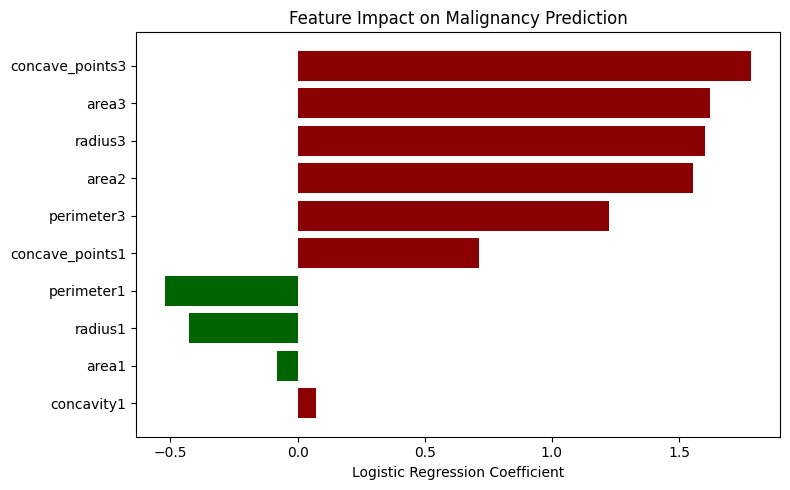

In [ ]:
#plot of Feature Importance (Coefficients)
feature_importance = pd.DataFrame({'Feature':top_10_features, 'Coefficient':model.coef_[0]})
feature_importance = feature_importance.sort_values('Coefficient', key=abs, ascending=True)

plt.figure(figsize=(8, 5))
colors = ['darkred' if x > 0 else 'darkgreen' for x in feature_importance['Coefficient']]
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors)
plt.xlabel('Logistic Regression Coefficient')
plt.title('Feature Impact on Malignancy Prediction')
plt.tight_layout()
plt.show()

In [ ]:
#Model Evaluation

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc:.4f} ({auc*100:.2f}%)")

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nCONFUSION MATRIX:")
print(f"                 Predicted")
print(f"                 Benign  Malignant")
print(f"Actual Benign    {cm[0,0]:5d}   {cm[0,1]:5d}")
print(f"Actual Malignant {cm[1,0]:5d}   {cm[1,1]:5d}")

Accuracy:  0.9649 (96.49%)
Precision: 0.9750 (97.50%)
Recall:    0.9286 (92.86%)
F1-Score:  0.9512
AUC-ROC:   0.9977 (99.77%)

CONFUSION MATRIX:
                 Predicted
                 Benign  Malignant
Actual Benign       71       1
Actual Malignant     3      39


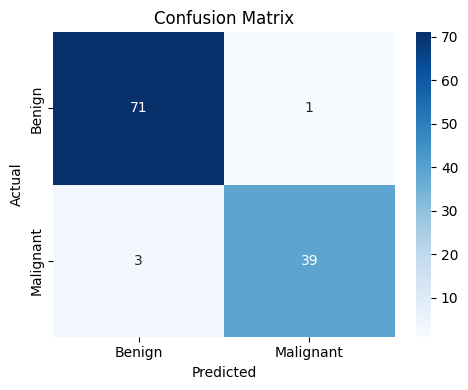

In [ ]:
#Confusion Matrix Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

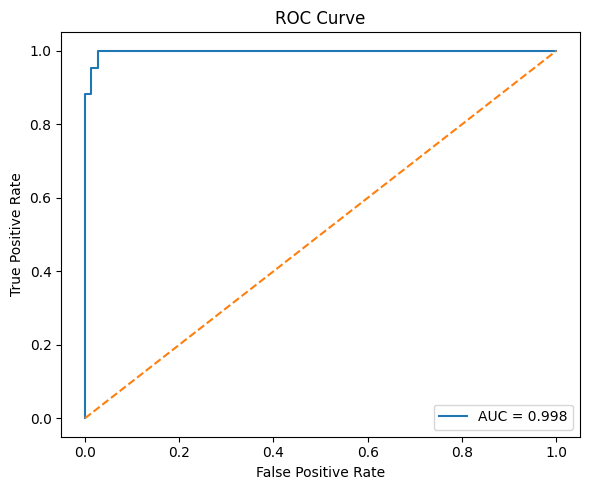

In [ ]:
#ROC Curve
plt.figure(figsize=(6, 5))
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()